# Finite Differences for the solution of Boundary Value Problems


In [14]:
# importing libraries
import numpy as np
import pandas as pd
import math
from matplotlib import pyplot as plt
from ipywidgets import interactive, fixed

We'll solve the following BVP using the linear shooting Method:

$$y'' = p(x)y' + q(x)y + r(x), \quad y(a) = \alpha,\quad y(b) = \beta.$$

Using the finite difference method. 

# Definition of the BVP

In [15]:
# Define the IVP:

# Diff. Eqn.: y'' = p(x)y' + q(x)y +r(x)
def p(x):
    return # p(x) 
def q(x):
    return # q(x)
def r(x):
    return # r(x) 

# Crout factorization and solve for tridiagonal linear systems

In [16]:
# Crout Factorization 
# input: tridiagonal entries of A:
#        dsub: lower diagonal
#           d: main diagonal
#        dsup: uppper diagonal
# output: Crout LU factorization

def crout(dsub,d,dsup):

    n = len(d)
    
    # definie L and U in Crout Factorization
    # dsub will be lower diagonal of L
    # d    will be diagonal of L
    # dsup will be upper diagonal of U
    for i in range(1,n):
        dsup[i-1] =       # U[i,i+1]
        d[i]      =       # L[i,i]

    return dsub, d, dsub

# Forward and Backward sub for tridiagonal systems
# input: tridiagonal entries of A:
#        dsub: lower diagonal
#           d: main diagonal
#        dsup: uppper diagonal
#         rhs: right-hand-side of system
# output: Crout LU factorization
def fbsub(dsub,d,dsup,rhs):

    n = len(d)
    z = np.zeros(n)  # intermediate variable for forward sub
    v = np.zeros(n)  # solution after backward sub
    
    ###############################################################
    # Forward sub:
    z[0] = rhs[0]/d[0]
    for i in range(1,n):
        z[i] = (rhs[i] -  )/d[i]

    ###############################################################
    # Backward sub:
    v[n-1] = z[n-1]
    for i in range(1,n):
        v[n-i-1] = 

    return v

# Boundary Value Problems (BVP)
## The Finite Difference Method

In [4]:
# Approximate solution to BVP using Finite Difference method 
# for 2nd-order ODE where 2nd-order central differences 
# used for y' and y''

def fdiff(a,b,alpha,beta,n):
    x    = np.zeros(n+2)   # independent var
    w    = np.zeros(n+2)   # dependent var
    # z    = np.zeros(n)     # intermediate variable for forward sub 
    d    = np.zeros(n)     # diagonal of nxn matrix A
    dsub = np.zeros(n-1)   # subdiagonal of nxn matrix A
    dsup = np.zeros(n-1)   # superdiagonal of nxn matrix A
    y    = np.zeros(n)     # RHS

    h    = (b-a)/(n+1)                   # step size
    x    = a + h*np.array(range(0,n+2))  # grid on [a,b] with step h

    ###############################################################
    # Define entries of nxn matrix A for 2nd-order ODE where
    # 2nd-order central differences used for y' and y''
    # row 1 of A
    d[0]    =  # diagonal entries
    dsup[0] =  # super diagonal entries
    y[0]    =  # RHS

    # rows 2 to n-1 of A
    for i in range(1,n-1):
        dsub[i-1] =    # sub-diagonal entries
        d[i]      =    # diagonal entries
        dsup[i]   =    # super-diagonal entries
        y[i]      =    # RHS

    # row n: i = n-1 of A
    dsub[n-2] =     # sub-diagonal entries
    d[n-1]    =     # diagonal entries
    y[n-1]    =     # RHS

    ###############################################################
    # Solve using Crout Factorization Method:
    # definie L and U where A = LU is tridiagonal
    crout(dsub,d,dsup)

    # ###############################################################
    # # perform solve using sequential forward & backward sub
    w[1:n+1] = fbsub(dsub,d,dsup,y)

    # Boundary conditions
    w[0]   = 
    w[n+1] = 
    
    # return grid points and approximate solution values
    return x,w


            x       w[i]       y(x)
0    0.000000  20.085537  20.085537
1    0.009901  19.497700  19.497710
2    0.019802  18.927068  18.927087
3    0.029703  18.373136  18.373163
4    0.039604  17.835415  17.835451
..        ...        ...        ...
97   0.960396   1.126151   1.126158
98   0.970297   1.093195   1.093200
99   0.980198   1.061203   1.061206
100  0.990099   1.030147   1.030149
101  1.000000   1.000000   1.000000

[102 rows x 3 columns]


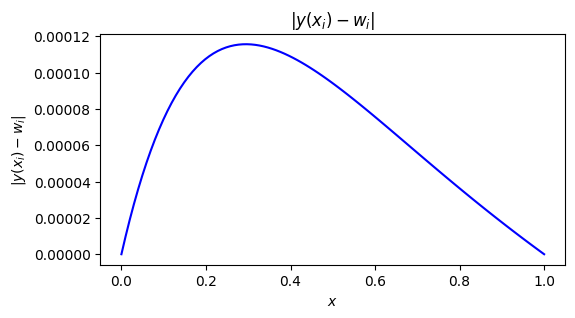

In [24]:
a     = 
b     = 
alpha = 
beta  = 
n     =
[x,w] = fdiff(a,b,alpha,beta,n)

yexact = 

plt.figure(figsize=(6, 3))
plt.plot(x,np.abs(yexact-w),'-',color='blue')
plt.xlabel(f'$x$')
plt.ylabel(f'$|y(x_i) - w_i|$')
plt.title(f'$|y(x_i) - w_i|$');

data = [x, w, yexact]
data = np.transpose(data)
print(pd.DataFrame(data, columns=["x", "w[i]","y(x)"]))